In [1]:
using Pkg
Pkg.activate("..")
Pkg.resolve()
Pkg.instantiate()
Pkg.precompile()
import HybridDynamics as HD
using LinearAlgebra
import Plots as plt

  Activating project at `c:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl`
     Project No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Project.toml`
    Manifest No packages added to or removed from `C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\Manifest.toml`


TESTING ADAPTIVE LMMS WITH GENERAL SYSTEMS

In [2]:
function f_cont(x, t)
    # Continuous dynamics: [velocity, constant acceleration]
    return [x[2], -9.81]
end

f_cont (generic function with 1 method)

In [3]:
function h_guard(x)
    # Guard surface: triggers when position hits 0
    return x[1] 
end

h_guard (generic function with 1 method)

In [4]:
function reset_map(x, t=0.0)
    return [x[1], -0.8 * x[2]]
end
# Adding the second argument 't' allows the Variational code to call it,

reset_map (generic function with 2 methods)

In [5]:
# Solve Standard System
sys = HD.GeneralSystem(f_cont, h_guard, reset_map)
prob = HD.prob(sys, [10.0, 0.0], (0.0, 15.0))
sol = HD.solve(prob, HD.RK23())

┌ Info: Zeno contraction detected. count: 1
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:95
┌ Info: Zeno contraction detected. count: 2
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:95
┌ Info: Zeno contraction detected. count: 3
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:95
┌ Warning: Max Zeno jumps reached at t = 12.561349999997834. Terminating.
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:98


HybridDynamics.GeneralSolution{Vector{Float64}}([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.07, 0.08, 0.09  …  12.561249999997838, 12.561259999997837, 12.561269999997837, 12.561279999997836, 12.561289999997836, 12.561299999997836, 12.561309999997835, 12.561319999997835, 12.561329999997835, 12.561339999997834], [[10.0, 0.0], [9.9995095, -0.0981], [9.998038000000001, -0.1962], [9.9955855, -0.2943], [9.992152, -0.3924], [9.987737500000001, -0.49050000000000005], [9.982342000000001, -0.5886], [9.975965500000001, -0.6867], [9.968608000000001, -0.7847999999999999], [9.9602695, -0.8828999999999999]  …  [2.8411079812022993e-6, -0.029552521600446875], [2.5450922651978307e-6, -0.029650621600446875], [2.248095549193362e-6, -0.029748721600446875], [1.9501178331888934e-6, -0.029846821600446875], [1.6511591171844247e-6, -0.029944921600446876], [1.351219401179956e-6, -0.030043021600446876], [1.0502986851754871e-6, -0.030141121600446876], [7.483969691710184e-7, -0.030239221600446876], 

In [7]:
# Plot Standard System
t_plot, X_plot = HD.split_jumps(sol)

# Extracting elements from a list of vectors
pos = [x[1] for x in X_plot]
vel = [x[2] for x in X_plot]

6430-element Vector{Float64}:
  0.0
 -0.0981
 -0.1962
 -0.2943
 -0.3924
 -0.49050000000000005
 -0.5886
 -0.6867
 -0.7847999999999999
 -0.8828999999999999
  ⋮
 -0.029650621600446875
 -0.029748721600446875
 -0.029846821600446875
 -0.029944921600446876
 -0.030043021600446876
 -0.030141121600446876
 -0.030239221600446876
 -0.030337321600446877
 -0.030435421600446877

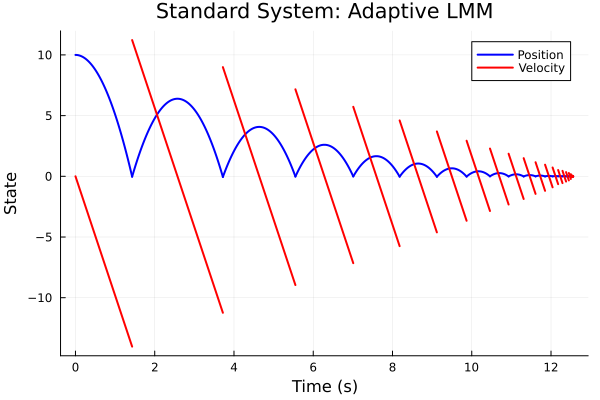

In [8]:
p1 = plt.plot(t_plot, pos, label="Position", xlabel="Time (s)", ylabel="State", lw=2, color=:blue)
plt.plot!(p1, t_plot, vel, label="Velocity", lw=2, color=:red)
plt.title!("Standard System: Adaptive LMM")
p1

VARIATIONAL EQUATION TEST WITH GENERAL SYSTEM

In [9]:
# Dynamics for [x, Φ]
#f_aug(U, t) = HD.variational_vector_field(f_cont, U, t)

#This is needed if you DO NOT use MagnusLeapfrog method.  

In [10]:
# Reset for [x, Φ]
function reset_aug(U)
    return HD.apply_variational_jump(U, f_cont, reset_map, h_guard, 0.0)
end

reset_aug (generic function with 1 method)

In [11]:
# Guard for augmented state (check guard on x component)
h_aug(U) = h_guard(U[:, 1])

h_aug (generic function with 1 method)

In [12]:
sys_aug = HD.GeneralSystem(f_cont, h_guard, reset_aug) #Change to f_aug if not using magnusLeapfrog
U0 = hcat([10.0, 0.0], Matrix{Float64}(I, 2, 2))
prob_aug = HD.prob(sys_aug, U0, (0.0, 10.0))
sol_aug = HD.solve(prob_aug, HD.MagnusLeapfrog())

┌ Info: Time step below minimum threshold 1.0e-6. Terminating.
└ @ HybridDynamics C:\Users\david\Desktop\Program\VSCode\HybridDynamics.jl\src\Systems\General.jl:259


HybridDynamics.GeneralSolution{Matrix{Float64}}([0.0, 0.01, 0.02, 0.03, 0.04, 0.05, 0.060000000000000005, 0.07, 0.08, 0.09  …  9.909999999999833, 9.919999999999833, 9.929999999999833, 9.939999999999833, 9.949999999999832, 9.959999999999832, 9.969999999999832, 9.979999999999832, 9.989999999999831, 9.999999999999831], [[10.0 1.0 0.0; 0.0 0.0 1.0], [9.9995095 1.0 0.01; -0.0981 0.0 1.0], [9.998038000000001 1.0 0.02; -0.1962 0.0 1.0], [9.9955855 1.0 0.03; -0.2943 0.0 1.0], [9.992152 1.0 0.04; -0.3924 0.0 1.0], [9.987737500000001 1.0 0.05; -0.49050000000000005 0.0 1.0], [9.982342000000001 1.0 0.060000000000000005; -0.5886 0.0 1.0], [9.975965500000001 1.0 0.07; -0.6867 0.0 1.0], [9.968608000000001 1.0 0.08; -0.7847999999999999 0.0 1.0], [9.9602695 1.0 0.09; -0.8828999999999999 0.0 1.0]  …  [0.0849128377024307 -1.2428544193579405 -0.25866137600001016; 2.5374680985600033 4.974978886948241 1.000000000000044], [0.10979701868803074 -1.193104630488458 -0.2486613760000097; 2.4393680985600033 4.97497

In [13]:
# Plot Augmented System
t_plot_aug, U_plot = HD.split_jumps(sol_aug)

pos_a   = [U[1, 1] for U in U_plot]
vel_a   = [U[2, 1] for U in U_plot]
phi_11  = [U[1, 2] for U in U_plot]
phi_12  = [U[1, 3] for U in U_plot]
phi_21  = [U[2, 2] for U in U_plot]
phi_22  = [U[2, 3] for U in U_plot];

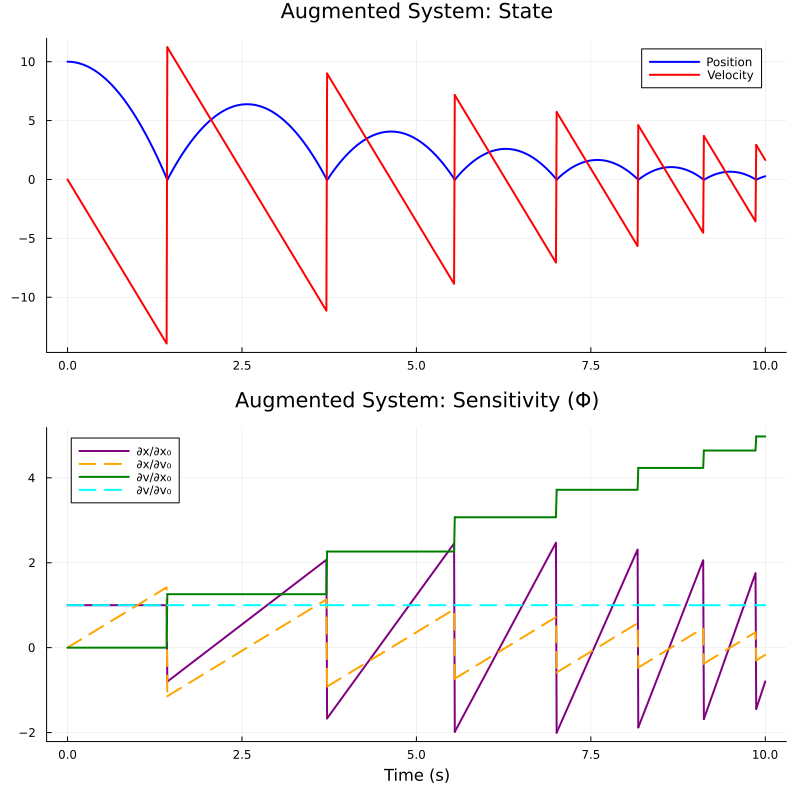

In [14]:
p2 = plt.plot(t_plot_aug, pos_a, label="Position", lw=2, color=:blue)
plt.plot!(p2, t_plot_aug, vel_a, label="Velocity", lw=2, color=:red)
plt.title!(p2, "Augmented System: State")

p3 = plt.plot(t_plot_aug, phi_11, label="∂x/∂x₀", lw=2, color=:purple)
plt.plot!(p3, t_plot_aug, phi_12, label="∂x/∂v₀", lw=2, color=:orange, linestyle=:dash)
plt.plot!(p3, t_plot_aug, phi_21, label="∂v/∂x₀", lw=2, color=:green)
plt.plot!(p3, t_plot_aug, phi_22, label="∂v/∂v₀", lw=2, color=:cyan, linestyle=:dash)
plt.title!(p3, "Augmented System: Sensitivity (Φ)")
plt.xlabel!(p3, "Time (s)")

final_plot = plt.plot(p2, p3, layout=(2,1), size=(800, 800))
display(final_plot)